# My Final Project

In [21]:
import numpy as np
import matplotlib.pyplot as plt 
import os

skip_chars = ['\\','|']

def filter_lines(filename):
    filtered_lines = []
    with open(filename, 'r') as file:
        for line in file:
            if not any(char in line for char in skip_chars):
                filtered_lines.append(line)
    
    from io import StringIO
    filtered_data = StringIO('\n'.join(filtered_lines))
    return np.loadtxt(filtered_data, delimiter = None)

data = filter_lines('vr.txt')
t0 = 2450000
x = data[:,0] - t0
y = data[:,1]
y_err = data[:,2]

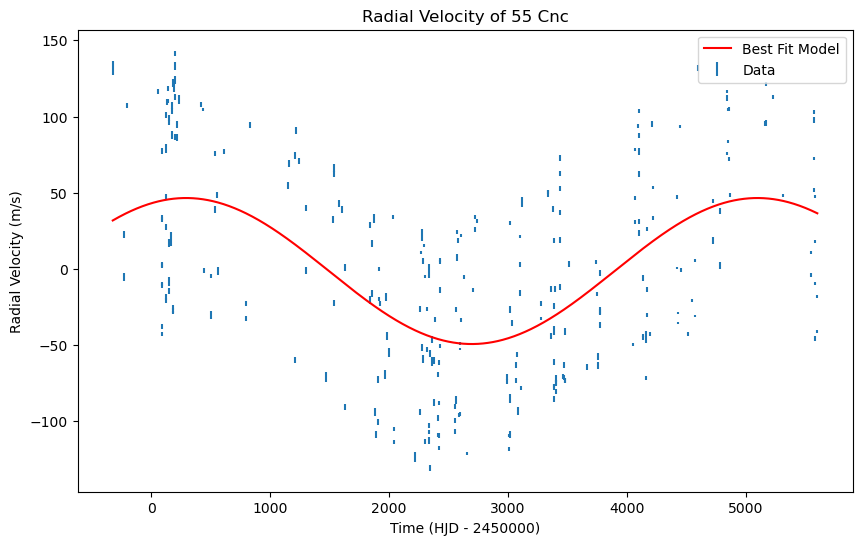

In [22]:
from scipy.optimize import curve_fit
npoints = 274

A_guess = 300 # amplitude
t0_guess = 2449676.0632 # x start (phase)
P_guess = 5100 # period
C_guess = 25 # mean value

def rv_model(t, A, P, t0, C):
    return A * np.sin(2 * np.pi * (t - t0) / P) + C

params, cov = curve_fit(rv_model, x, y, sigma=y_err,
                        p0=[A_guess, P_guess, t0_guess, C_guess])
A_fit, P_fit, t0_fit, C_fit = params

t_fit = np.linspace(min(x), max(x), 1000)
rv_fit = rv_model(t_fit, A_fit, P_fit, t0_fit, C_fit)

plt.figure(figsize=(10,6))

plt.errorbar(x, y, yerr=y_err, fmt='none', label='Data')
plt.plot(t_fit, rv_fit, color='red', label='Best Fit Model')

plt.xlabel("Time (HJD - 2450000)")
plt.ylabel("Radial Velocity (m/s)")
plt.title("Radial Velocity of 55 Cnc")
plt.legend()

plt.show()

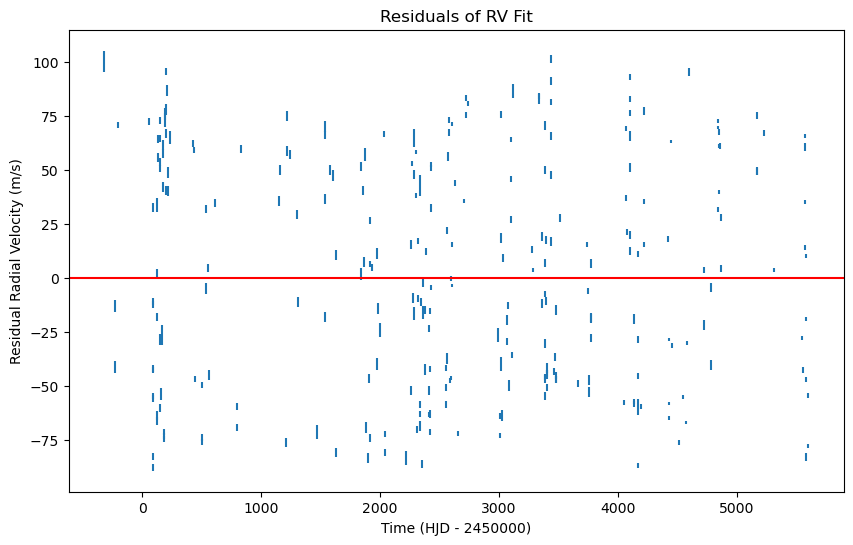

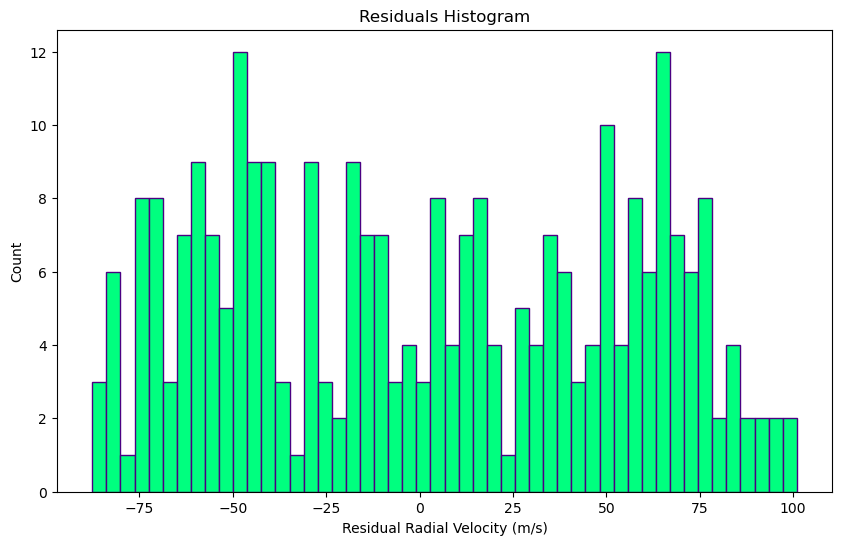

Standard Deviation of Residuals: 52.2120743102033
Mean Experimental Error: 1.8060667343065693


In [23]:
rv_model_data = rv_model(x, A_fit, P_fit, t0_fit, C_fit)
residuals = y - rv_model_data

plt.figure(figsize=(10,6))
plt.errorbar(x, residuals, yerr=y_err, fmt='none')
plt.axhline(0, color='red')
plt.xlabel("Time (HJD - 2450000)")
plt.ylabel("Residual Radial Velocity (m/s)")
plt.title("Residuals of RV Fit")
plt.show()

plt.figure(figsize=(10,6))
plt.hist(residuals, bins=50, color='springgreen', edgecolor='indigo')
plt.xlabel("Residual Radial Velocity (m/s)")
plt.ylabel("Count")
plt.title("Residuals Histogram")
plt.show()

std_residuals = np.std(residuals)
print("Standard Deviation of Residuals:", std_residuals)
print("Mean Experimental Error:", np.mean(y_err))

The standard deviation of the residuals is much greater than the predicted experimental error. This is a meaningful result because it tells us that a single sinusoid does not fully explain the radial velocity of the star. This is most likely because the 55 Cancri system contains multiple planets, according to the NASA exoplanet archive.

In [24]:
K = abs(A_fit)
P = P_fit
M_star = 0.905

M_planet = (K / 28.4) * ((P / 365)**(1/3)) * (M_star**(2/3))

print("Orbital Period (days):", P)
print("Radial Velocity Amplitude (m/s):", K)
print("Estimated Planet Mass (Jupiter masses):", M_planet)

Orbital Period (days): 4807.090437184041
Radial Velocity Amplitude (m/s): 47.91754317589998
Estimated Planet Mass (Jupiter masses): 3.7279641875972755


The estimated orbital period of my exoplanet is 4807 days, which closely resembles the dominant planet of the 55 Cnc system: 55 Cancri d, which has an orbital period of 4799 days according to the NASA exoplanet archive. In conclusion, the radial velocity data is consistent with the exoplanet 55 Cancri d.